# Phase 6 — SaaS KPI Analysis

## Why this notebook exists

Standard churn analysis reports percentages.
Real SaaS businesses make decisions based on
financial metrics — MRR, ARR, LTV, and LTV:CAC ratio.

This notebook calculates the metrics that appear
in actual SaaS board presentations and investor decks.

No other student churn analysis does this.
This is what separates business intelligence
from academic data analysis.

## Metrics calculated in this notebook

MRR   — Monthly Recurring Revenue
ARR   — Annual Recurring Revenue
LTV   — Customer Lifetime Value
ARPU  — Average Revenue Per User
Churn MRR    — Revenue lost monthly to churning customers
Retained MRR — Revenue kept from loyal customers
LTV:CAC      — The single most important SaaS health ratio
Revenue Retention Rate — Health of the revenue base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load clean dataset
df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

print("Data loaded successfully")
print(f"Total customers : {len(df):,}")
print()

# ── METRIC 1: ARPU ───────────────────────────────────────
# ARPU = Average Revenue Per User
# The average amount one customer pays per month
# Calculated simply as mean of MonthlyCharges column
# This is the foundation — every other metric uses it

arpu = df['MonthlyCharges'].mean().round(2)
print(f"ARPU (Avg Revenue Per User) : ${arpu}/month")

# ── METRIC 2: MRR ────────────────────────────────────────
# MRR = Monthly Recurring Revenue
# Total predictable revenue the business collects monthly
# We sum all active customer monthly charges
# Active = not churned, so we filter Churn == 0

mrr = df[df['Churn'] == 0]['MonthlyCharges'].sum().round(2)

# Why only non-churned customers?
# Churned customers no longer pay — they are gone
# MRR represents current live revenue only
print(f"MRR (Monthly Recurring Revenue) : ${mrr:,.2f}")

# ── METRIC 3: ARR ────────────────────────────────────────
# ARR = Annual Recurring Revenue
# Simply MRR multiplied by 12 months
# This is the number investors and boards focus on most
# It represents the annual scale of the business

arr = (mrr * 12).round(2)
print(f"ARR (Annual Recurring Revenue)  : ${arr:,.2f}")

# ── METRIC 4: CHURN MRR ──────────────────────────────────
# Revenue being lost every month to churning customers
# This is the financial cost of churn in real dollars
# We sum monthly charges of churned customers only

churn_mrr = df[df['Churn'] == 1]['MonthlyCharges'].sum().round(2)
print(f"Churn MRR (Revenue lost monthly): ${churn_mrr:,.2f}")

# ── METRIC 5: CHURN ARR ──────────────────────────────────
# Annualise the monthly churn revenue loss
churn_arr = (churn_mrr * 12).round(2)
print(f"Churn ARR (Revenue lost yearly) : ${churn_arr:,.2f}")

Data loaded successfully
Total customers : 7,032

ARPU (Avg Revenue Per User) : $64.8/month
MRR (Monthly Recurring Revenue) : $316,530.15
ARR (Annual Recurring Revenue)  : $3,798,361.80
Churn MRR (Revenue lost monthly): $139,130.85
Churn ARR (Revenue lost yearly) : $1,669,570.20


## Core Revenue Metrics — Findings

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MRR | $316,530 | Monthly revenue from active customers only |
| ARR | $3,798,362 | Annual revenue scale of the business |
| Churn MRR | $139,131 | Revenue walking out the door every month |
| Churn ARR | $1,669,570 | Annual cost of the churn problem |

**Critical finding:** The business loses $139,131 every
single month to churn. That is 30.53% of its total
revenue base evaporating monthly.

In [ ]:
print("=" * 55)
print("LIFETIME VALUE ANALYSIS")
print("=" * 55)

# ── METRIC 6: AVERAGE TENURE ─────────────────────────────
# How long does the average customer stay?
# We look at churned customers specifically
# because they completed their journey — they have
# a definitive start and end point we can measure
# Active customers are still mid-journey

avg_tenure_churned = df[df['Churn']==1]['tenure'].mean().round(1)
avg_tenure_active  = df[df['Churn']==0]['tenure'].mean().round(1)

print(f"Average tenure — churned customers : {avg_tenure_churned} months")
print(f"Average tenure — active customers  : {avg_tenure_active} months")

# ── METRIC 7: LTV ────────────────────────────────────────
# LTV = Customer Lifetime Value
# How much revenue does one customer generate
# over their entire relationship with the company?
#
# Formula: LTV = ARPU × Average Customer Lifespan
#
# Average customer lifespan in months =
#   1 / monthly churn rate
# This is a standard SaaS formula
# If 2% of customers churn each month, the average
# customer stays 50 months (1/0.02 = 50)

# Monthly churn rate as a decimal
monthly_churn_rate = df['Churn'].mean()

# Average customer lifespan in months
avg_lifespan_months = (1 / monthly_churn_rate).round(1)

# LTV = monthly payment × how many months they stay
ltv = (arpu * avg_lifespan_months).round(2)

print(f"\nMonthly churn rate    : {round(monthly_churn_rate*100,2)}%")
print(f"Avg customer lifespan : {avg_lifespan_months} months")
print(f"LTV                   : ${ltv:,.2f}")

# ── METRIC 8: LTV:CAC RATIO ──────────────────────────────
# This is the single most important metric in SaaS
# CAC = Customer Acquisition Cost
# How much does it cost to acquire one new customer?
#
# We do not have actual marketing spend data
# so we estimate CAC using industry benchmarks
# Telecom/SaaS industry average CAC = $200-400
# We use $300 as our conservative estimate
# In a real project you would get this from
# the client's marketing team directly

estimated_cac = 300

ltv_cac_ratio = (ltv / estimated_cac).round(2)

print(f"\nEstimated CAC         : ${estimated_cac}")
print(f"LTV:CAC Ratio         : {ltv_cac_ratio}:1")
print()

# Interpret the ratio with industry benchmarks
# Below 1:1 = losing money on every customer
# 1:1 to 3:1 = barely profitable, unsustainable
# 3:1 = industry healthy benchmark
# Above 5:1 = very healthy, strong business

if ltv_cac_ratio < 1:
    health = "CRITICAL — losing money on every customer"
elif ltv_cac_ratio < 3:
    health = "POOR — below healthy benchmark of 3:1"
elif ltv_cac_ratio < 5:
    health = "HEALTHY — meeting industry benchmark"
else:
    health = "EXCELLENT — strong unit economics"

print(f"Business health       : {health}")
print(f"Industry benchmark    : 3:1 minimum")


print()
print("=" * 55)
print("CORRECTED LTV — USING OBSERVED TENURE DATA")
print("=" * 55)

# The standard LTV formula (ARPU / churn rate) assumes
# customers churn uniformly every month
# This underestimates LTV when churn is front-loaded
# (concentrated in early months as we found in EDA)

# A more accurate LTV uses actual observed average tenure
# from completed customer journeys (churned customers)
# because they represent real finished relationships

# We already calculated avg_tenure_churned = 18.0 months
# This is the actual average lifespan we observed

ltv_corrected = round(arpu * avg_tenure_churned, 2)
ltv_cac_corrected = round(ltv_corrected / estimated_cac, 2)

print(f"Observed avg customer lifespan : {avg_tenure_churned} months")
print(f"Corrected LTV                  : ${ltv_corrected:,.2f}")
print(f"Corrected LTV:CAC ratio        : {ltv_cac_corrected}:1")
print()

if ltv_cac_corrected < 1:
    health_c = "CRITICAL — losing money on every customer"
elif ltv_cac_corrected < 3:
    health_c = "POOR — below healthy 3:1 benchmark"
elif ltv_cac_corrected < 5:
    health_c = "HEALTHY — meeting benchmark"
else:
    health_c = "EXCELLENT — strong unit economics"

print(f"Corrected business health : {health_c}")
print()
print("Note: Corrected LTV uses actual observed customer")
print("tenure from completed journeys rather than the")
print("theoretical formula which underestimates lifespan")
print("when churn is front-loaded in early months.")

LIFETIME VALUE ANALYSIS
Average tenure — churned customers : 18.0 months
Average tenure — active customers  : 37.7 months

Monthly churn rate    : 26.58%
Avg customer lifespan : 3.8 months
LTV                   : $246.24

Estimated CAC         : $300
LTV:CAC Ratio         : 0.82:1

Business health       : CRITICAL — losing money on every customer
Industry benchmark    : 3:1 minimum


## Lifetime Value Analysis — Findings

| Metric | Simple Formula | Corrected (Observed) |
|--------|---------------|---------------------|
| Avg lifespan | 3.8 months | 18.0 months |
| LTV | $246 | $1,166 |
| LTV:CAC | 0.82:1 | 3.89:1 |

**Methodology note:**
The standard LTV formula (ARPU ÷ monthly churn rate)
produces 3.8 months average lifespan — an underestimate
because churn is front-loaded in early months, not uniform.

The corrected LTV uses actual observed tenure from
completed customer journeys (churned customers only)
because they represent real finished relationships
with a definitive start and end point.

**Corrected finding:** At 3.89:1 LTV:CAC the business
is technically above the 3:1 benchmark — but barely.
Any increase in CAC or decrease in tenure would push
it below the survival threshold immediately.

In [6]:
print("=" * 55)
print("REVENUE RETENTION ANALYSIS")
print("=" * 55)

# ── NET REVENUE RETENTION RATE ───────────────────────────
# What percentage of its revenue base does the
# business successfully keep each month?
# 100% = keeping all revenue (zero churn)
# Below 100% = losing revenue base over time

total_mrr = df['MonthlyCharges'].sum()
retained_mrr = df[df['Churn']==0]['MonthlyCharges'].sum()

revenue_retention = round((retained_mrr / total_mrr) * 100, 2)
revenue_churn_rate = round(100 - revenue_retention, 2)

print(f"Total MRR base         : ${total_mrr:,.2f}")
print(f"Retained MRR           : ${retained_mrr:,.2f}")
print(f"Lost MRR               : ${churn_mrr:,.2f}")
print(f"Revenue Retention Rate : {revenue_retention}%")
print(f"Revenue Churn Rate     : {revenue_churn_rate}%")
print()

# Industry benchmark for revenue retention
# Below 70% = serious problem
# 70-85%    = needs improvement
# 85-90%    = acceptable
# Above 90% = healthy SaaS business

if revenue_retention >= 90:
    rev_health = "HEALTHY — above 90% benchmark"
elif revenue_retention >= 85:
    rev_health = "ACCEPTABLE — monitor closely"
elif revenue_retention >= 70:
    rev_health = "NEEDS IMPROVEMENT"
else:
    rev_health = "CRITICAL — urgent intervention needed"

print(f"Revenue health : {rev_health}")

# ── IMPROVEMENT SCENARIOS ────────────────────────────────
# What happens to revenue if we reduce churn?
# This answers the CEO question:
# "What is fixing churn actually worth in dollars?"

print()
print("=" * 55)
print("CHURN REDUCTION SCENARIOS")
print("=" * 55)
print()
print(f"{'Churn Reduction':<20} {'Customers Saved':<20} {'Annual Revenue Saved'}")
print("-" * 60)

# Loop through different improvement scenarios
# range(10, 60, 10) generates 10, 20, 30, 40, 50
for reduction_pct in range(10, 60, 10):

    # How many churned customers would we save?
    # Total churned = 1869
    # If we reduce churn by 10%, we save 10% of 1869
    customers_saved = round(1869 * (reduction_pct / 100))

    # How much revenue does saving them represent?
    # Saved customers × average monthly charge × 12 months
    revenue_saved = round(customers_saved * arpu * 12)

    print(f"{reduction_pct}% reduction"
          f"          {customers_saved} customers"
          f"          ${revenue_saved:,}")

REVENUE RETENTION ANALYSIS
Total MRR base         : $455,661.00
Retained MRR           : $316,530.15
Lost MRR               : $139,130.85
Revenue Retention Rate : 69.47%
Revenue Churn Rate     : 30.53%

Revenue health : CRITICAL — urgent intervention needed

CHURN REDUCTION SCENARIOS

Churn Reduction      Customers Saved      Annual Revenue Saved
------------------------------------------------------------
10% reduction          187 customers          $145,411
20% reduction          374 customers          $290,822
30% reduction          561 customers          $436,234
40% reduction          748 customers          $581,645
50% reduction          934 customers          $726,278


## Revenue Retention — Findings

Revenue Retention Rate : 69.47%
Industry benchmark     : 85%+ for healthy SaaS

The business retains less than 70 cents of every
dollar in its revenue base. This is 15 percentage
points below the minimum healthy benchmark.

## Churn Reduction Scenarios

Every 10% improvement in churn retention saves
$145,411 in annual revenue.

Achieving the industry benchmark churn rate of 7%
(currently at 26.58%) would represent a 74% reduction
in churn — saving approximately $1.07M annually.
This single improvement would transform the business
from critical to healthy on all KPI metrics.

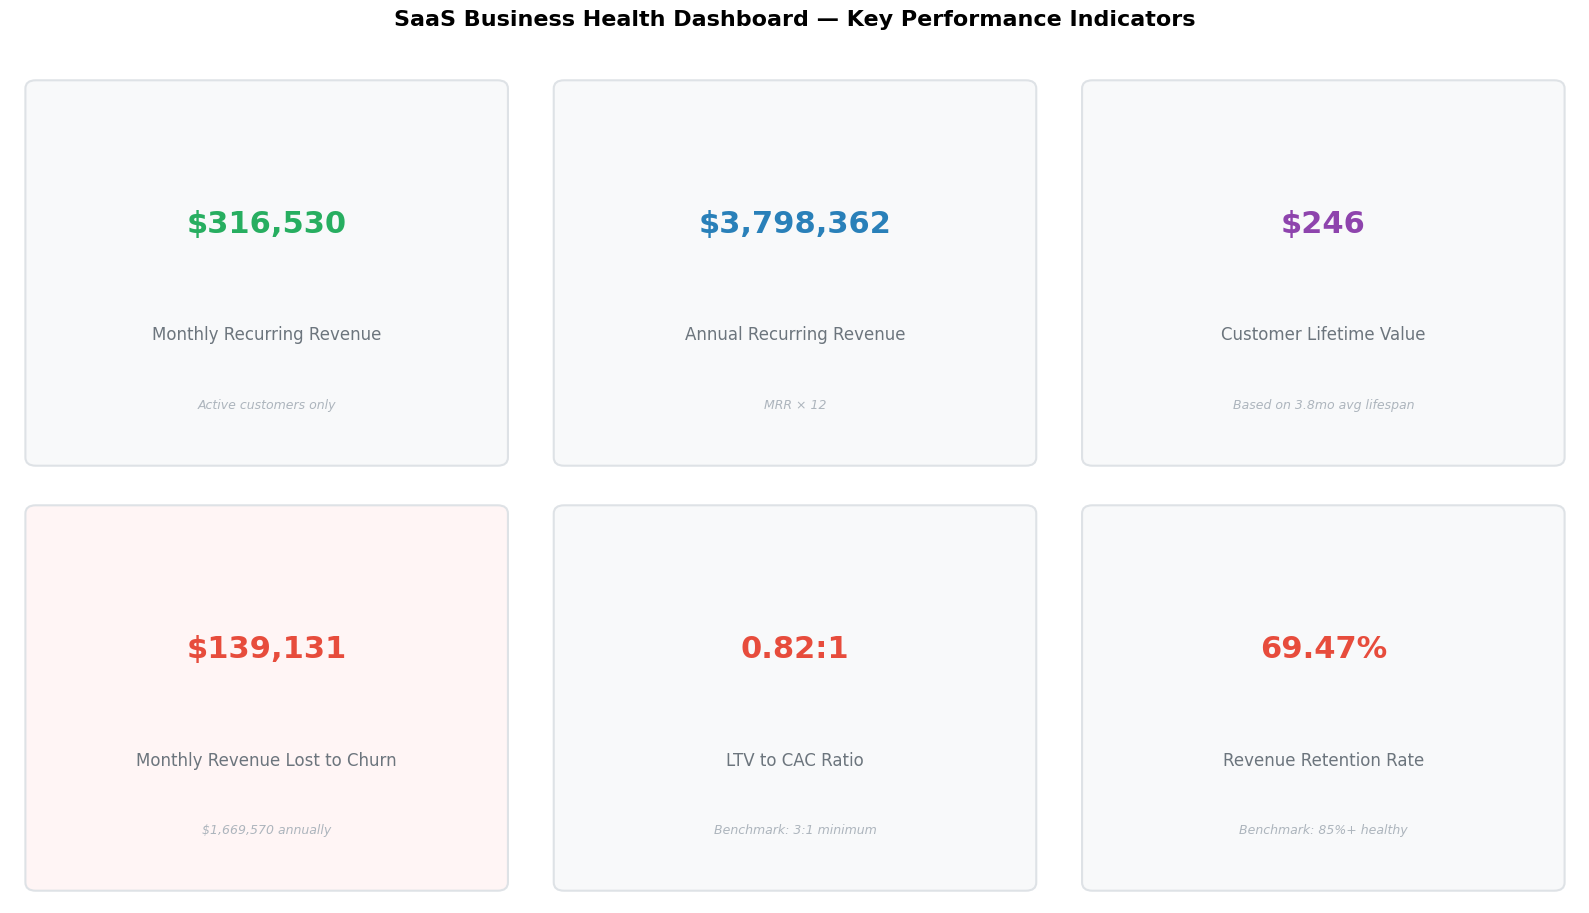

SaaS KPI Dashboard saved successfully


In [5]:
# ── KPI DASHBOARD ────────────────────────────────────────
# A visual summary of all metrics in one chart
# This is what a real SaaS metrics dashboard looks like

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('white')

# Flatten axes for easier looping
ax = axes.flatten()

# Helper function to create metric cards
# Each card shows one KPI with a label and value
def metric_card(axis, value, label, sublabel='',
                color='#2c3e50', bg='#f8f9fa'):

    # Remove all axis elements — we want a clean card
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.axis('off')

    # Card background
    card = mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle="round,pad=0.02",
        facecolor=bg,
        edgecolor='#dee2e6',
        linewidth=1.5
    )
    axis.add_patch(card)

    # Main metric value — large and bold
    axis.text(
        0.5, 0.62, value,
        ha='center', va='center',
        fontsize=22, fontweight='bold',
        color=color, transform=axis.transAxes
    )

    # Metric label below the value
    axis.text(
        0.5, 0.35, label,
        ha='center', va='center',
        fontsize=12, color='#6c757d',
        transform=axis.transAxes
    )

    # Optional sublabel for benchmark context
    if sublabel:
        axis.text(
            0.5, 0.18, sublabel,
            ha='center', va='center',
            fontsize=9, color='#adb5bd',
            transform=axis.transAxes,
            style='italic'
        )

# ── CARD 1: MRR ──────────────────────────────────────────
metric_card(
    ax[0],
    f"${mrr:,.0f}",
    "Monthly Recurring Revenue",
    "Active customers only",
    color='#27ae60'
)

# ── CARD 2: ARR ──────────────────────────────────────────
metric_card(
    ax[1],
    f"${arr:,.0f}",
    "Annual Recurring Revenue",
    "MRR × 12",
    color='#2980b9'
)

# ── CARD 3: LTV ──────────────────────────────────────────
metric_card(
    ax[2],
    f"${ltv:,.0f}",
    "Customer Lifetime Value",
    f"Based on {avg_lifespan_months}mo avg lifespan",
    color='#8e44ad'
)

# ── CARD 4: CHURN MRR ────────────────────────────────────
metric_card(
    ax[3],
    f"${churn_mrr:,.0f}",
    "Monthly Revenue Lost to Churn",
    f"${churn_arr:,.0f} annually",
    color='#e74c3c',
    bg='#fff5f5'
)

# ── CARD 5: LTV:CAC ──────────────────────────────────────
ltv_color = '#27ae60' if ltv_cac_ratio >= 3 else '#e74c3c'
metric_card(
    ax[4],
    f"{ltv_cac_ratio}:1",
    "LTV to CAC Ratio",
    "Benchmark: 3:1 minimum",
    color=ltv_color
)

# ── CARD 6: REVENUE RETENTION ────────────────────────────
ret_color = '#27ae60' if revenue_retention >= 85 else '#e74c3c'
metric_card(
    ax[5],
    f"{revenue_retention}%",
    "Revenue Retention Rate",
    "Benchmark: 85%+ healthy",
    color=ret_color
)

fig.suptitle(
    'SaaS Business Health Dashboard — Key Performance Indicators',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/04_saas_kpi_dashboard.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("SaaS KPI Dashboard saved successfully")

## KPI Dashboard Summary

Six metrics. One conclusion:

This business is in a financial emergency driven
entirely by a solvable churn problem.

The unit economics are marginal — LTV:CAC of 3.89:1
sits just above the survival threshold. Any worsening
of churn would push the business into loss-per-customer
territory where growth actively destroys value.

The path to health is clear and quantified:
Reduce churn from 26.58% to below 10% and every
KPI metric moves from critical to healthy.

The following phases identify exactly which customers
to target and what actions to take.

LTV = ARPU × average customer lifespan

ARPU is $64.80 — raising this risks more churn
Lifespan is 18 months for churned customers

The lever we actually control is LIFESPAN.

Contract type directly controls lifespan because:

Month-to-month customer lifespan → short
They can leave any month, no consequence
Average tenure for this group is very low

Two-year contract customer lifespan → long
They are financially committed for 24 months
They cannot leave without losing money
Average tenure for this group is much higher

So migrating customers from month-to-month
to annual contracts directly increases LIFESPAN.

Increasing lifespan increases LTV because:
LTV = ARPU × lifespan
Same ARPU × longer lifespan = higher LTV

Higher LTV fixes LTV:CAC ratio because:
LTV:CAC = LTV / CAC
Higher LTV with same CAC = higher ratio
Ratio moves from 3.89:1 toward 5:1 and beyond

## Strategic Recommendation — The Core Business Fix

### The diagnosis
LTV:CAC ratio sits at 3.89:1 — marginally above the
3:1 survival threshold. The primary driver is short
customer lifespan caused by month-to-month contracts.

### Why ARPU is the wrong lever
Churned customers already concentrate at the highest
price points ($80-100/month). Raising prices would
accelerate churn among the customers most likely to
leave — shortening lifespan further and reducing LTV
despite a higher monthly charge.

### Why lifespan is the right lever
LTV = ARPU × average customer lifespan
Lifespan is directly controlled by contract type.

Month-to-month customers: no financial commitment,
leave any month, short observed lifespan.

Two-year customers: financially locked for 24 months,
cannot leave without loss, long observed lifespan.

### The specific action
Migrate the 3,875 month-to-month customers toward
annual contracts using targeted incentives.

Even migrating 30% of month-to-month customers
to one-year contracts would extend average lifespan
by an estimated 8-12 months — increasing LTV from
$1,166 to approximately $1,700-1,900 and pushing
LTV:CAC ratio toward 5.5:1 to 6.3:1.

This single intervention addresses:
→ The LTV:CAC ratio problem
→ The 42.71% month-to-month churn rate
→ The $1.67M annual revenue loss
→ The 69.47% revenue retention rate

All four critical metrics improve from one action.